In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from pyro_cases.utils.run_non_amoretized_vae_with_fixed_design import train_and_test_non_amortized_vae_with_fixed_design
from pyro_cases.utils.run_mcmc_with_fixed_design import train_and_test_mcmc_with_fixed_design

In [3]:
device = torch.device("cuda:6")
task_name = "arm_electric_one_pred"
n_samples = 2000
seed = 123456
test_seed = 7272

In [4]:
def move_dict_to_device(pre_dict: dict, device):
    return {
        k: v.to(device=device) if isinstance(v, torch.Tensor) else v
        for k, v in pre_dict.items()
    }

In [5]:
vae_out_dict = train_and_test_non_amortized_vae_with_fixed_design(task_name=task_name,
                                                                    seed=seed,
                                                                    device=device,
                                                                    lr=1e-2,
                                                                    num_particles=1,
                                                                    vectorize_particles=False,
                                                                    steps=10_000,
                                                                    test_seed=test_seed,
                                                                    num_test_obs=1,
                                                                    show_progress=True,
                                                                    return_vae=True,
                                                                    suppress_error=False,
                                                                    use_natural_gradient=True)

100%|██████████| 10000/10000 [02:13<00:00, 75.08it/s]


[task arm_electric_one_pred seed 123456 completes] task start time: Sat Aug 23 21:51:51 2025; task end time: Sat Aug 23 21:54:04 2025; cost time: 133.2 seconds


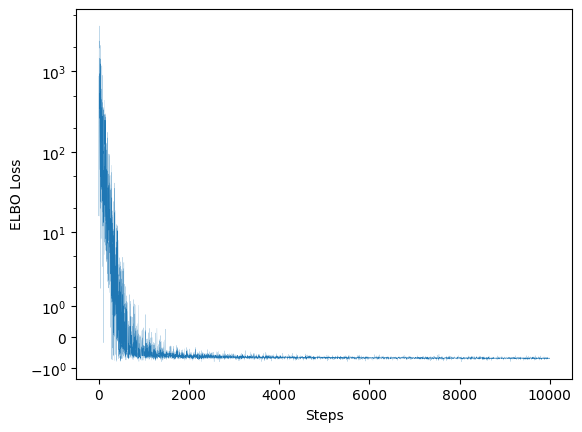

In [6]:
plt.plot(vae_out_dict["elbo_training_loss"], linewidth=0.1)
plt.xlabel("Steps")
plt.ylabel("ELBO Loss")
plt.yscale("asinh")
plt.show()

In [7]:
vae_out_dict["elbo_param_raw_theta1_trace"].shape, vae_out_dict["elbo_param_raw_theta2_trace"].shape

(torch.Size([10000, 1, 2]), torch.Size([10000, 1, 2]))

In [8]:
def plot_theta_trace(theta_trace, label):
    num_param = theta_trace.shape[0]  # (num_param, steps)
    fig, axes = plt.subplots(num_param // 2, 2, figsize=(8, 2 * num_param), constrained_layout=True)
    for i, (sub_theta_trace, ax) in enumerate(zip(theta_trace, axes.flatten())):
        ax.plot(sub_theta_trace)
        ax.set_xlabel("Steps")
        ax.set_ylabel(f"{label}[{i + 1}]")
    fig.show()

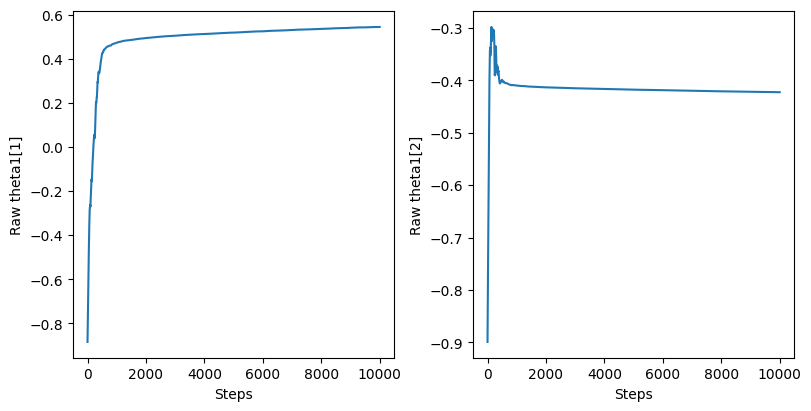

In [9]:
plot_theta_trace(vae_out_dict["elbo_param_raw_theta1_trace"].squeeze(1).T, label="Raw theta1")

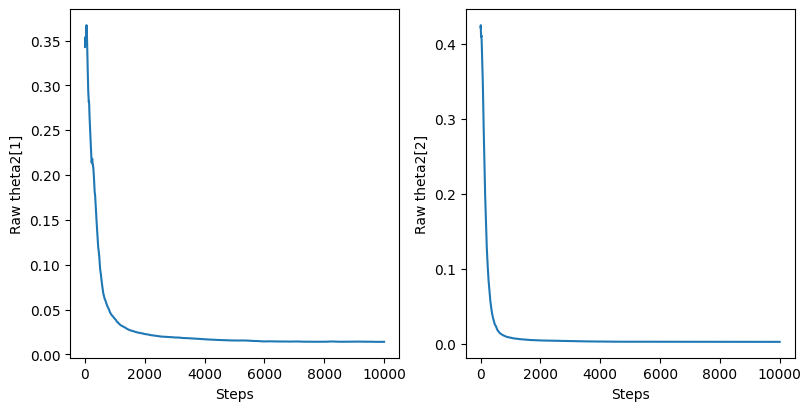

In [10]:
plot_theta_trace(vae_out_dict["elbo_param_raw_theta2_trace"].squeeze(1).T, label="Raw theta2")

In [11]:
vae_samples = vae_out_dict["elbo_vae"].variational_dist.draw_samples(
    vae_out_dict["elbo_test_result_dict"]["raw_pred"],
    n_samples
)

In [12]:
vae_samples.shape

torch.Size([1, 2, 2000])

In [13]:
vae_samples = vae_samples[0]

In [14]:
mcmc_out_dict = train_and_test_mcmc_with_fixed_design(task_name=task_name,
                                                      seed=seed,
                                                      device=device,
                                                      test_sample_dict=move_dict_to_device(vae_out_dict["elbo_test_sample_dict"], device=device),
                                                      warmup_steps=500,
                                                      n_samples=n_samples)

Sample: 100%|██████████| 2500/2500 [01:27, 28.64it/s, step size=3.40e-01, acc. prob=0.939]

[task arm_electric_one_pred seed 123456 completes] task start time: Sat Aug 23 21:54:06 2025; task end time: Sat Aug 23 21:55:33 2025; cost time: 87.3 seconds


In [15]:
print(mcmc_out_dict["mcmc_object"].summary())


                mean       std    median      5.0%     95.0%     n_eff     r_hat
 beta[0,0]      0.56      0.03      0.55      0.51      0.60    448.51      1.00
 beta[0,1]     -0.42      0.01     -0.42     -0.43     -0.42    502.53      1.00

Number of divergences: 0
None


In [16]:
mcmc_out_dict["mcmc_samples"]["beta"].shape

torch.Size([2000, 1, 2])

In [17]:
mcmc_samples = mcmc_out_dict["mcmc_samples"]["beta"].squeeze(1).permute([1, 0])

In [18]:
vae_samples.shape, mcmc_samples.shape

(torch.Size([2, 2000]), torch.Size([2, 2000]))

In [19]:
def plot_marginal_comparison(vae_samples, mcmc_samples):
    assert vae_samples.shape[0] == mcmc_samples.shape[0]
    ndim = vae_samples.shape[0]
    fig, axs = plt.subplots(nrows=ndim, ncols=2, figsize=(8, ndim * 4),
                            constrained_layout=True)
    for i, r_axes in enumerate(axs):
        sns.histplot(vae_samples[i], ax=r_axes[0], label="VAE", kde=True, color="green")
        sns.histplot(mcmc_samples[i], ax=r_axes[1], label="MCMC", kde=True, color="blue")
        for ax in r_axes:
            ax.set_title(f"Param {i + 1}")
            ax.legend()
    fig.show()

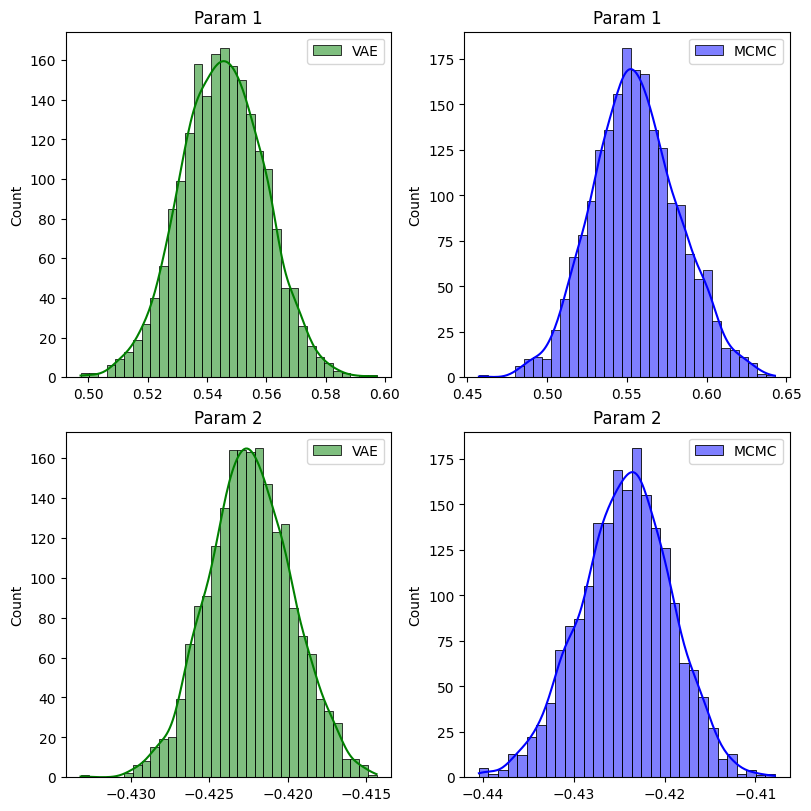

In [20]:
plot_marginal_comparison(vae_samples, mcmc_samples)